# Flight Price Analysis, ML, and Power BI Dataset Preparation

This notebook is organized for GitHub readability and practical delivery:

1. Data loading and quality checks  
2. Cleaning and feature engineering  
3. Insight generation (EDA + KPI tables)  
4. Machine learning pipeline  
5. Hyperparameter tuning with `GridSearchCV`  
6. Export files for an attractive Power BI dashboard

## 1) Setup and Imports

In [22]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

sns.set_theme(style='whitegrid')

## 2) Load Data

In [23]:
DATA_PATH = 'flights.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (15000, 12)


,index,airline,date_of_journey,Source,destination,route,dep_time,Arrival_time,Duration,Total_stops,Additional_info,Price
0,1,AirAsia India,2024-02-25,Guwahati,Indore,GUW-NAG-MUM-RAI-IND,01:39,14:15,3h 15min,3 stops,Red-eye flight,14170
1,2,TruJet,2021-03-01,Nagpur,Pune,NAG-PUN,06:48,03:21,1h 0min,non-stop,1 Long layover,10295
2,3,Star Air,2024-04-11,Ahmedabad,Varanasi,AHM-PUN-BAN-VAR,08:54,15:50,14h 30min,2 stops,In-flight meal not included,9165
3,4,SpiceJet,2019-03-13,Patna,Indore,PAT-LUC-GOA-BHU-IND,18:09,08:23,7h 15min,3 stops,No info,9944
4,5,SpiceJet,2023-06-22,Raipur,Mumbai,RAI-GOA-MUM,15:05,05:52,15h 30min,1 stop,1 Long layover,9474


## 3) Data Profiling and Initial Audit

In [24]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index            15000 non-null  int64 
 1   airline          15000 non-null  object
 2   date_of_journey  15000 non-null  object
 3   Source           15000 non-null  object
 4   destination      15000 non-null  object
 5   route            15000 non-null  object
 6   dep_time         15000 non-null  object
 7   Arrival_time     15000 non-null  object
 8   Duration         15000 non-null  object
 9   Total_stops      15000 non-null  object
 10  Additional_info  15000 non-null  object
 11  Price            15000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.4+ MB


In [25]:
profile = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'null_count': df_raw.isna().sum(),
    'null_pct': (df_raw.isna().mean() * 100).round(2),
    'n_unique': df_raw.nunique()
}).sort_values(['null_pct', 'n_unique'], ascending=[False, False])
profile

,dtype,null_count,null_pct,n_unique
index,int64,0,0.0,15000
route,object,0,0.0,10761
Price,int64,0,0.0,8785
date_of_journey,object,0,0.0,2350
dep_time,object,0,0.0,1440
Arrival_time,object,0,0.0,1440
Duration,object,0,0.0,60
Source,object,0,0.0,20
destination,object,0,0.0,20
airline,object,0,0.0,10


## 4) Cleaning and Feature Engineering

### Business-ready columns created
- `journey_year`, `journey_month`, `journey_day`, `journey_weekday`, `is_weekend`
- `duration_minutes`, `duration_hours`
- `stops_num`
- `dep_hour`, `dep_minute`, `arr_hour`, `arr_minute`
- `dep_time_block` (Early Morning / Morning / Afternoon / Evening / Night)

In [26]:
df = df_raw.copy()

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# Drop non-informative ID if present
if 'index' in df.columns:
    df = df.drop(columns=['index'])

# Parse date
if 'date_of_journey' in df.columns:
    df['date_of_journey'] = pd.to_datetime(df['date_of_journey'], errors='coerce')
    df['journey_year'] = df['date_of_journey'].dt.year
    df['journey_month'] = df['date_of_journey'].dt.month
    df['journey_day'] = df['date_of_journey'].dt.day
    df['journey_weekday'] = df['date_of_journey'].dt.day_name()
    df['is_weekend'] = df['journey_weekday'].isin(['Saturday', 'Sunday']).astype(int)

# Convert duration text like "7h 30min" into total minutes

def duration_to_minutes(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower().strip()
    h_match = re.search(r'(\d+)\s*h', text)
    m_match = re.search(r'(\d+)\s*min', text)
    hours = int(h_match.group(1)) if h_match else 0
    minutes = int(m_match.group(1)) if m_match else 0
    return hours * 60 + minutes

if 'duration' in df.columns:
    df['duration_minutes'] = df['duration'].apply(duration_to_minutes)
    df['duration_hours'] = (df['duration_minutes'] / 60).round(2)

# Convert stops text into integer
if 'total_stops' in df.columns:
    stops_map = {
        'non-stop': 0,
        '1 stop': 1,
        '2 stops': 2,
        '3 stops': 3,
        '4 stops': 4
    }
    df['stops_num'] = (
        df['total_stops']
        .astype(str)
        .str.strip()
        .str.lower()
        .map(stops_map)
    )

# Parse times
for col in ['dep_time', 'arrival_time']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%H:%M', errors='coerce')

if 'dep_time' in df.columns:
    df['dep_hour'] = df['dep_time'].dt.hour
    df['dep_minute'] = df['dep_time'].dt.minute

if 'arrival_time' in df.columns:
    df['arr_hour'] = df['arrival_time'].dt.hour
    df['arr_minute'] = df['arrival_time'].dt.minute

# Time block for better dashboard slicing
if 'dep_hour' in df.columns:
    bins = [-1, 5, 11, 16, 20, 23]
    labels = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
    df['dep_time_block'] = pd.cut(df['dep_hour'], bins=bins, labels=labels)

# Extra predictive features

# Route frequency encoding
if 'route' in df.columns:
    route_freq = df['route'].value_counts(dropna=False)
    df['route_freq'] = df['route'].map(route_freq).astype(float)

if 'route' in df.columns:
    df['route_len'] = df['route'].astype(str).str.count('-') + 1

if {'source', 'destination'}.issubset(df.columns):
    df['same_city'] = (df['source'].astype(str).str.lower() == df['destination'].astype(str).str.lower()).astype(int)

if 'additional_info' in df.columns:
    ai = df['additional_info'].astype(str).str.lower()
    df['is_red_eye'] = ai.str.contains('red-eye').astype(int)
    df['has_long_layover'] = ai.str.contains('long layover').astype(int)

# Cyclical encoding for hours/month improves tree splits on circular time patterns
for hcol, pfx in [('dep_hour', 'dep'), ('arr_hour', 'arr')]:
    if hcol in df.columns:
        df[f'{pfx}_hour_sin'] = np.sin(2 * np.pi * df[hcol] / 24)
        df[f'{pfx}_hour_cos'] = np.cos(2 * np.pi * df[hcol] / 24)

if 'journey_month' in df.columns:
    df['month_sin'] = np.sin(2 * np.pi * df['journey_month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['journey_month'] / 12)

df.head()

,airline,date_of_journey,source,destination,route,dep_time,arrival_time,duration,total_stops,additional_info,price,journey_year,journey_month,journey_day,journey_weekday,is_weekend,duration_minutes,duration_hours,stops_num,dep_hour,dep_minute,arr_hour,arr_minute,dep_time_block,route_freq,route_len,same_city,is_red_eye,has_long_layover,dep_hour_sin,dep_hour_cos,arr_hour_sin,arr_hour_cos,month_sin,month_cos
0,AirAsia India,2024-02-25,Guwahati,Indore,GUW-NAG-MUM-RAI-IND,1900-01-01 01:39:00,1900-01-01 14:15:00,3h 15min,3 stops,Red-eye flight,14170,2024,2,25,Sunday,1,195,3.25,3,1,39,14,15,Early Morning,1.0,5,0,1,0,0.258819,9.659258e-01,-0.500000,-0.866025,8.660254e-01,5.000000e-01
1,TruJet,2021-03-01,Nagpur,Pune,NAG-PUN,1900-01-01 06:48:00,1900-01-01 03:21:00,1h 0min,non-stop,1 Long layover,10295,2021,3,1,Monday,0,60,1.00,0,6,48,3,21,Morning,11.0,2,0,0,1,1.000000,6.123234e-17,0.707107,0.707107,1.000000e+00,6.123234e-17
2,Star Air,2024-04-11,Ahmedabad,Varanasi,AHM-PUN-BAN-VAR,1900-01-01 08:54:00,1900-01-01 15:50:00,14h 30min,2 stops,In-flight meal not included,9165,2024,4,11,Thursday,0,870,14.50,2,8,54,15,50,Morning,1.0,4,0,0,0,0.866025,-5.000000e-01,-0.707107,-0.707107,8.660254e-01,-5.000000e-01
3,SpiceJet,2019-03-13,Patna,Indore,PAT-LUC-GOA-BHU-IND,1900-01-01 18:09:00,1900-01-01 08:23:00,7h 15min,3 stops,No info,9944,2019,3,13,Wednesday,0,435,7.25,3,18,9,8,23,Evening,1.0,5,0,0,0,-1.000000,-1.836970e-16,0.866025,-0.500000,1.000000e+00,6.123234e-17
4,SpiceJet,2023-06-22,Raipur,Mumbai,RAI-GOA-MUM,1900-01-01 15:05:00,1900-01-01 05:52:00,15h 30min,1 stop,1 Long layover,9474,2023,6,22,Thursday,0,930,15.50,1,15,5,5,52,Afternoon,1.0,3,0,0,1,-0.707107,-7.071068e-01,0.965926,0.258819,1.224647e-16,-1.000000e+00


In [27]:
print('Cleaned shape:', df.shape)
print('\nNull counts after engineering:')
print(df.isna().sum().sort_values(ascending=False).head(15))


Cleaned shape: (15000, 35)

Null counts after engineering:
airline            0
date_of_journey    0
source             0
destination        0
route              0
dep_time           0
arrival_time       0
duration           0
total_stops        0
additional_info    0
price              0
journey_year       0
journey_month      0
journey_day        0
journey_weekday    0
dtype: int64


## 5) Required Insights (EDA)

In [28]:
# KPI snapshot
kpi = {
    'records': len(df),
    'avg_price': round(df['price'].mean(), 2),
    'median_price': round(df['price'].median(), 2),
    'min_price': int(df['price'].min()),
    'max_price': int(df['price'].max()),
    'avg_duration_hr': round(df['duration_hours'].mean(), 2),
    'avg_stops': round(df['stops_num'].mean(), 2)
}

kpi_df = pd.DataFrame([kpi])
kpi_df

,records,avg_price,median_price,min_price,max_price,avg_duration_hr,avg_stops
0,15000,9355.35,9354.0,2502,17900,8.37,1.5


In [29]:
# Top airlines by average fare
airline_summary = (
    df.groupby('airline', as_index=False)
      .agg(avg_price=('price', 'mean'), flights=('airline', 'count'))
      .sort_values('avg_price', ascending=False)
)
airline_summary.head(10)

,airline,avg_price,flights
2,Akasa Air,9478.975366,1502
3,Alliance Air,9459.429907,1498
8,TruJet,9430.778278,1556
6,SpiceJet,9426.612840,1542
0,Air India,9388.538047,1485
4,GoAir,9388.475432,1506
9,Vistara,9331.903614,1411
1,AirAsia India,9276.030843,1459
7,Star Air,9194.838624,1512
5,IndiGo,9174.490517,1529


In [30]:
# Top source-destination pairs by demand and fare
route_summary = (
    df.groupby(['source', 'destination'], as_index=False)
      .agg(flights=('price', 'count'), avg_price=('price', 'mean'))
      .sort_values(['flights', 'avg_price'], ascending=[False, False])
)
route_summary.head(15)

,source,destination,flights,avg_price
332,Raipur,Indore,55,9211.945455
159,Hyderabad,Guwahati,54,9770.370370
50,Bhubaneswar,Mumbai,54,8977.092593
363,Varanasi,Bhubaneswar,54,8942.462963
347,Surat,Delhi,53,10258.358491
105,Delhi,Kolkata,53,9522.566038
138,Guwahati,Delhi,53,9219.396226
316,Pune,Lucknow,53,8947.169811
77,Cochin,Bangalore,52,10299.615385
221,Kolkata,Mumbai,52,10062.211538


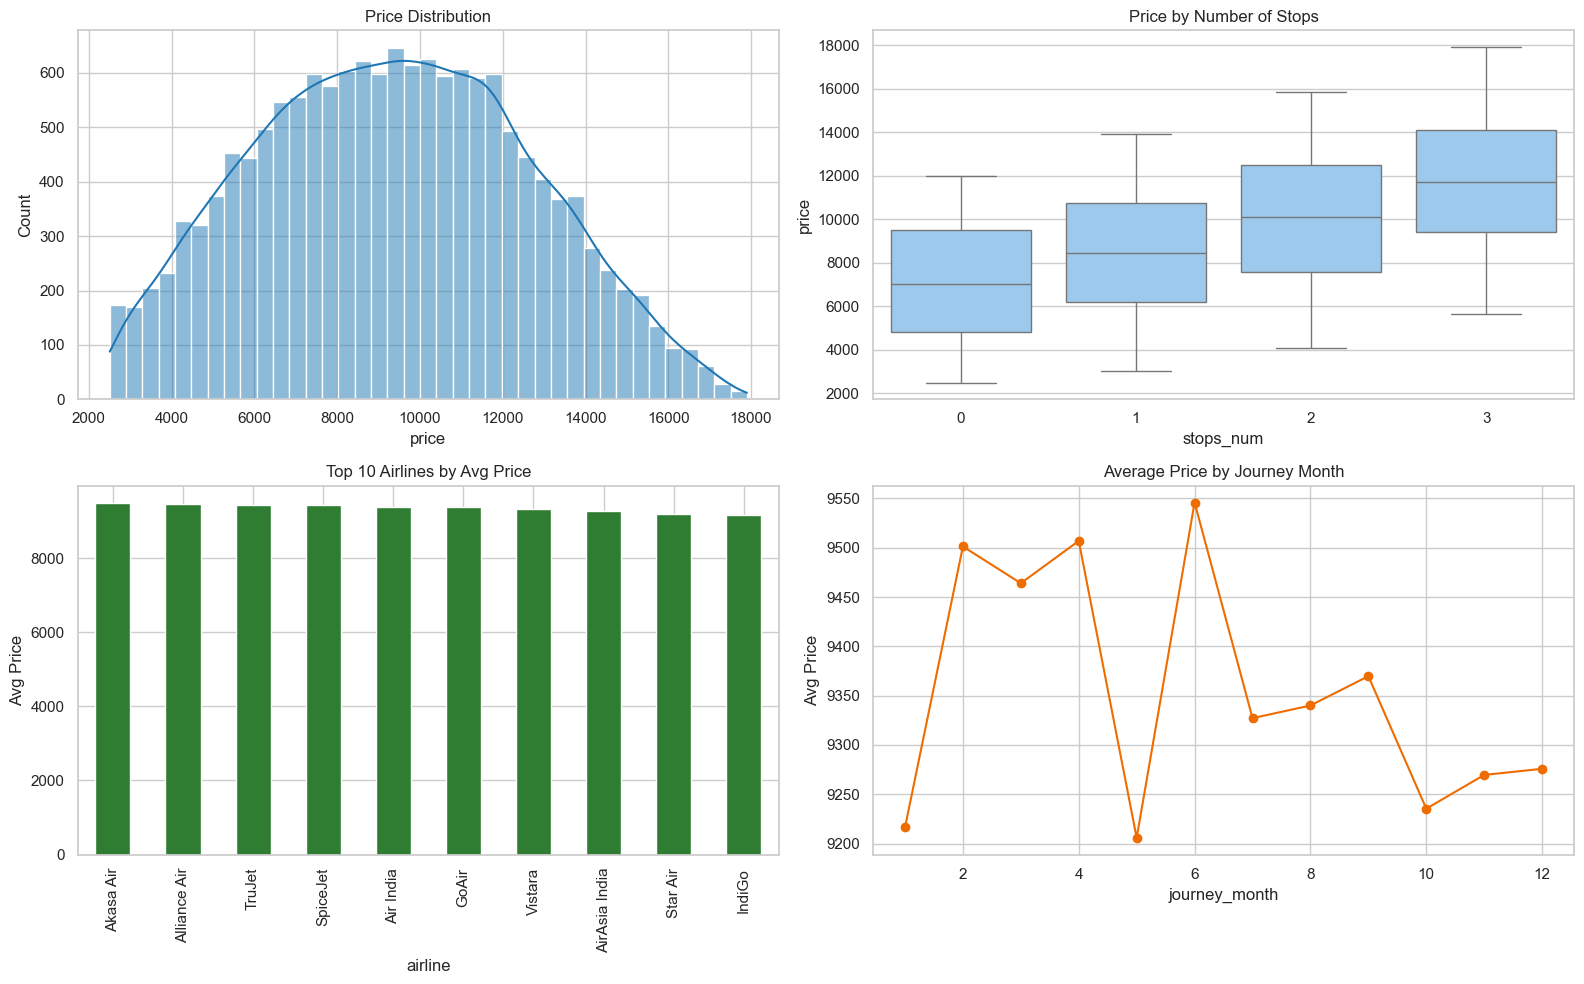

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['price'], kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Price Distribution')

sns.boxplot(data=df, x='stops_num', y='price', ax=axes[0, 1], color='#90caf9')
axes[0, 1].set_title('Price by Number of Stops')

(
    df.groupby('airline')['price'].mean()
      .sort_values(ascending=False)
      .head(10)
      .plot(kind='bar', ax=axes[1, 0], color='#2e7d32')
)
axes[1, 0].set_title('Top 10 Airlines by Avg Price')
axes[1, 0].set_ylabel('Avg Price')

(
    df.groupby('journey_month')['price'].mean()
      .plot(kind='line', marker='o', ax=axes[1, 1], color='#ef6c00')
)
axes[1, 1].set_title('Average Price by Journey Month')
axes[1, 1].set_ylabel('Avg Price')

plt.tight_layout()
plt.show()

## 6) Machine Learning Pipeline

Target: `price`  
Model strategy: compare multiple regressors, auto-select best by holdout `R2`, then tune with `GridSearchCV`.

In [32]:
# Feature set for modeling
model_df = df.copy()

# Drop columns that can cause leakage or duplicate transformed information
drop_cols = ['price', 'date_of_journey', 'dep_time', 'arrival_time', 'duration', 'route']
X = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])
y = model_df['price']

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

def make_ttr(regressor):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', regressor)
    ])
    return TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fast model comparison on a train subset for speed
cmp_n = min(8000, len(X_train))
X_train_cmp = X_train.sample(n=cmp_n, random_state=42)
y_train_cmp = y_train.loc[X_train_cmp.index]

candidate_models = {
    'ExtraTrees': ExtraTreesRegressor(
        random_state=42,
        n_estimators=180,
        max_features='sqrt',
        n_jobs=-1
    ),
    'RandomForest': RandomForestRegressor(
        random_state=42,
        n_estimators=180,
        max_features='sqrt',
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        random_state=42,
        n_estimators=220,
        learning_rate=0.05,
        max_depth=3
    )
}

model_rows = []
trained_candidates = {}
for name, reg in candidate_models.items():
    model = make_ttr(reg)
    model.fit(X_train_cmp, y_train_cmp)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    model_rows.append({'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    trained_candidates[name] = model

model_comparison = pd.DataFrame(model_rows).sort_values('R2', ascending=False).reset_index(drop=True)
best_model_name = model_comparison.loc[0, 'Model']
baseline_model = trained_candidates[best_model_name]

# Baseline metrics from auto-selected best model
y_pred = baseline_model.predict(X_test)

def regression_metrics(y_true, y_hat):
    r2 = r2_score(y_true, y_hat)
    mae = mean_absolute_error(y_true, y_hat)
    rmse = np.sqrt(mean_squared_error(y_true, y_hat))
    mape = np.mean(np.abs((y_true - y_hat) / y_true)) * 100
    return pd.Series({'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape})

baseline_metrics = regression_metrics(y_test, y_pred)

print('Auto-selected best baseline model:', best_model_name)
model_comparison

Auto-selected best baseline model: GradientBoosting


,Model,R2,MAE,RMSE
0,GradientBoosting,0.237886,2464.325057,2882.214071
1,RandomForest,0.228672,2473.557726,2899.585257
2,ExtraTrees,0.225603,2478.704365,2905.347878


In [33]:
# Optional: CV estimate for selected baseline model (can be slow)
RUN_CV = False
if RUN_CV:
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(baseline_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    print('CV R2 scores:', np.round(cv_r2, 4))
    print('CV R2 mean:', round(cv_r2.mean(), 4))
else:
    print('CV skipped. Set RUN_CV = True to run cross-validation.')

CV skipped. Set RUN_CV = True to run cross-validation.


## 7) Hyperparameter Tuning with GridSearchCV

Note: This can take time depending on machine specs.

In [34]:
# Dynamic hyperparameter grid based on selected model family
if best_model_name == 'ExtraTrees':
    grid_regressor = ExtraTreesRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'regressor__model__n_estimators': [180, 280],
        'regressor__model__max_depth': [None, 30],
        'regressor__model__min_samples_split': [2, 4],
        'regressor__model__min_samples_leaf': [1, 2],
        'regressor__model__max_features': ['sqrt']
    }
elif best_model_name == 'RandomForest':
    grid_regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'regressor__model__n_estimators': [180, 280],
        'regressor__model__max_depth': [None, 30],
        'regressor__model__min_samples_split': [2, 4],
        'regressor__model__min_samples_leaf': [1, 2],
        'regressor__model__max_features': ['sqrt']
    }
else:
    grid_regressor = GradientBoostingRegressor(random_state=42)
    param_grid = {
        'regressor__model__n_estimators': [180, 260],
        'regressor__model__learning_rate': [0.03, 0.07],
        'regressor__model__max_depth': [2, 3],
        'regressor__model__min_samples_split': [2, 5],
        'regressor__model__min_samples_leaf': [1, 2]
    }

tune_base = make_ttr(grid_regressor)

grid = GridSearchCV(
    estimator=tune_base,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print('Best model family:', best_model_name)
print('Best Params:', grid.best_params_)
print('Best CV R2:', round(grid.best_score_, 4))

tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
tuned_metrics = regression_metrics(y_test, y_pred_tuned)

results_compare = pd.DataFrame({
    'Baseline_Selected': baseline_metrics,
    'Tuned_Best': tuned_metrics
})
results_compare

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best model family: GradientBoosting
Best Params: {'regressor__model__learning_rate': 0.03, 'regressor__model__max_depth': 2, 'regressor__model__min_samples_leaf': 1, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 180}
Best CV R2: 0.2504


,Baseline_Selected,Tuned_Best
R2,0.237886,0.247613
MAE,2464.325057,2448.202332
RMSE,2882.214071,2863.762356
MAPE_%,30.666746,30.429624


## 8) Save Model Artifacts

In [35]:
os.makedirs('artifacts', exist_ok=True)
joblib.dump(tuned_model, 'artifacts/flight_price_model.joblib')
joblib.dump(list(X.columns), 'artifacts/model_features.joblib')
print('Saved model artifacts to artifacts/')

Saved model artifacts to artifacts/


## 9) Prepare Power BI-Ready Tables

These exports are designed for a clean dashboard model:
- `powerbi_flights_cleaned.csv` (fact-like detailed table)
- `powerbi_kpi.csv` (single-row KPI table)
- `powerbi_airline_summary.csv`
- `powerbi_route_summary.csv`
- `powerbi_monthly_summary.csv`

In [36]:
os.makedirs('powerbi_exports', exist_ok=True)

# Detailed table for slicing/dicing in Power BI
powerbi_flights = df.copy()
powerbi_flights.to_csv('powerbi_exports/powerbi_flights_cleaned.csv', index=False)

# KPI table
kpi_df.to_csv('powerbi_exports/powerbi_kpi.csv', index=False)

# Airline summary
airline_summary_out = airline_summary.copy()
airline_summary_out['avg_price'] = airline_summary_out['avg_price'].round(2)
airline_summary_out.to_csv('powerbi_exports/powerbi_airline_summary.csv', index=False)

# Route summary
route_summary_out = route_summary.copy()
route_summary_out['avg_price'] = route_summary_out['avg_price'].round(2)
route_summary_out.to_csv('powerbi_exports/powerbi_route_summary.csv', index=False)

# Monthly summary
monthly_summary = (
    df.groupby(['journey_year', 'journey_month'], as_index=False)
      .agg(avg_price=('price', 'mean'), flights=('price', 'count'))
      .sort_values(['journey_year', 'journey_month'])
)
monthly_summary['avg_price'] = monthly_summary['avg_price'].round(2)
monthly_summary.to_csv('powerbi_exports/powerbi_monthly_summary.csv', index=False)

print('Power BI exports generated in powerbi_exports/')

Power BI exports generated in powerbi_exports/


## 10) Power BI Dashboard Blueprint (Attractive Layout)

Use this page structure in Power BI for a polished result:

1. Executive Overview  
Cards: Avg Price, Median Price, Max Price, Total Flights  
Line Chart: Avg Price by Month  
Bar Chart: Avg Price by Airline (Top 10)

2. Route Intelligence  
Matrix: Source -> Destination with Avg Price and Flights  
Bar Chart: Top 15 busiest routes  
Slicers: Airline, Stops, Journey Month, Time Block

3. Operational Patterns  
Box Plot equivalent (custom visual): Price by Stops  
Column Chart: Avg Price by Departure Time Block  
Heatmap: Weekday vs Month avg fare

4. Model Insights  
Table: Baseline vs Tuned metrics  
Card: Best CV R2  
Optional: Predicted vs Actual scatter from exported scoring output

## 11) Final Notes

- If training time is high, reduce the GridSearch space.
- For deployment, wrap preprocessing + model inside the saved pipeline (already done).
- For GitHub: keep outputs visible for the key KPI/metrics cells and hide noisy logs.